# Kubernetes End-to-End: Senior Engineer Guide

> **Coverage:** Architecture → All K8s Objects → Networking → Storage → RBAC → Scaling → **Local Lab: SQLite DB + HTTP Server Tests**

---

## Why Kubernetes Exists

Kubernetes solves the **container orchestration problem** at scale. Without it, you manually:
- Restart crashed containers
- Distribute load across servers
- Roll out updates without downtime
- Manage secrets and configs

### Availability Mathematics

For a system with $n$ independent replicas each with failure rate $\lambda$, the system uptime is:

$$P(\text{system up}) = 1 - \lambda^n$$

With **3 replicas** and $\lambda = 0.01$ (1% failure rate per replica):

$$P(\text{up}) = 1 - (0.01)^3 = 1 - 10^{-6} = 99.9999\%$$

### SLA Nines Reference

| SLA | Downtime/Year | K8s replicas needed |
|-----|--------------|---------------------|
| 99% | 3.65 days | 1 |
| 99.9% | 8.77 hours | 2 |
| 99.99% | 52 minutes | 3 |
| 99.999% | 5.26 minutes | 5+ |

### Desired State Formula

K8s control loop follows:

$$\text{action} = f(\text{desired\_state} - \text{actual\_state})$$

This is a **closed-loop control system** - continuously reconciling toward the desired state.

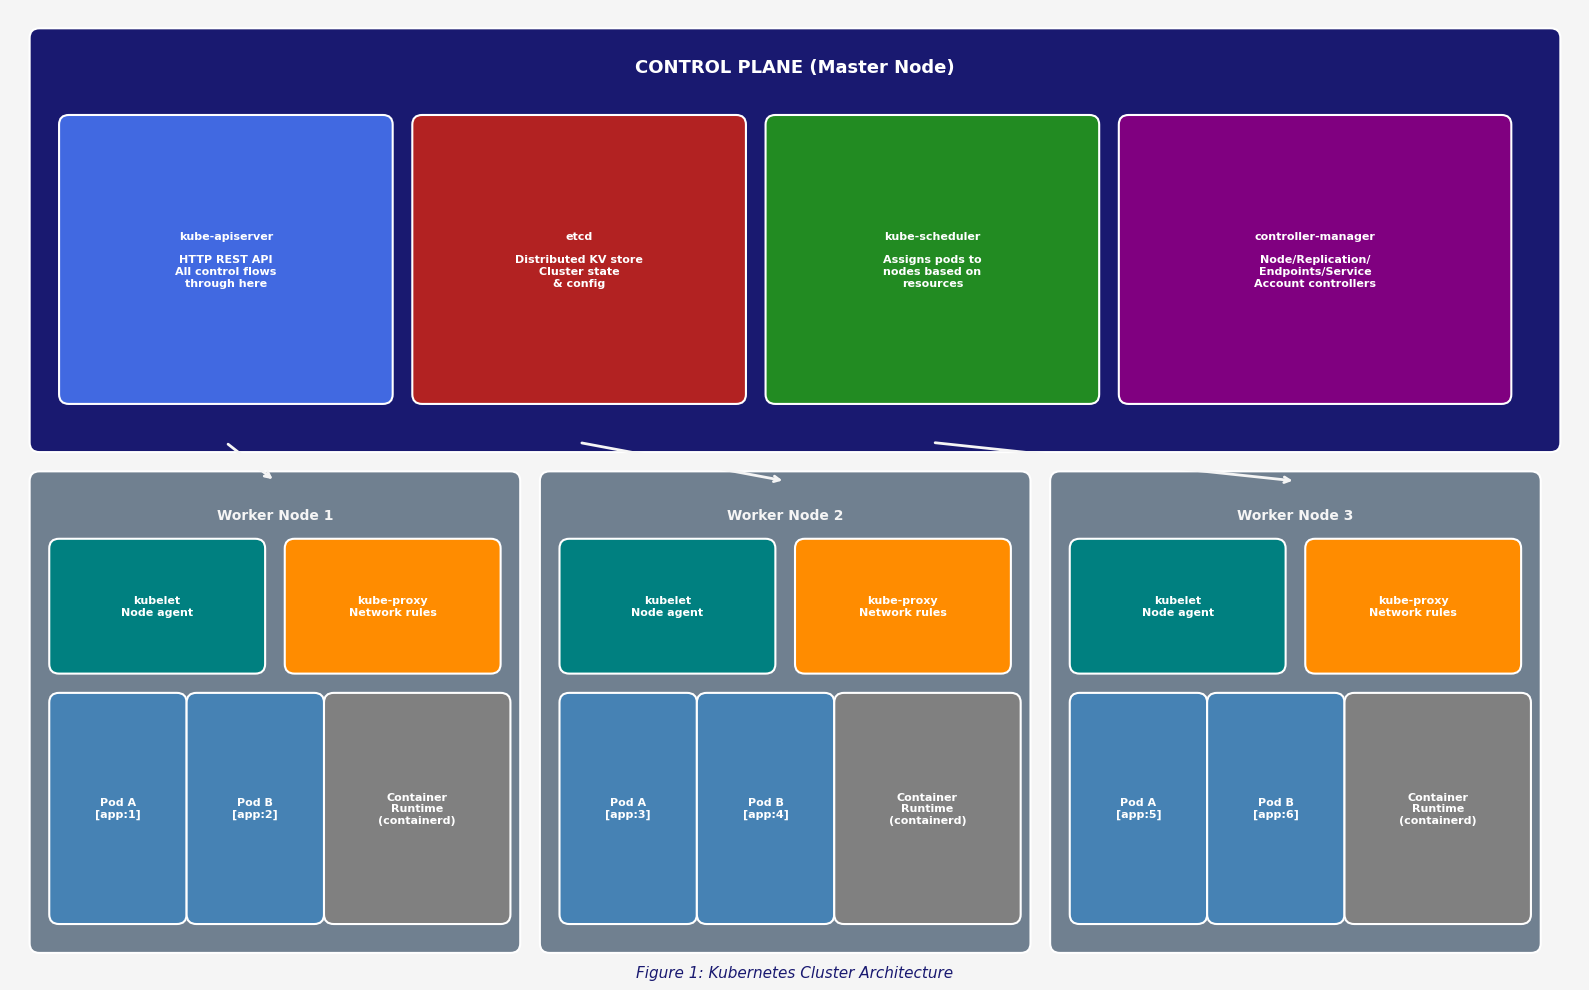

Architecture diagram rendered.


In [14]:
# Cell 1: K8s Architecture Diagram
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_facecolor('whitesmoke')
fig.patch.set_facecolor('whitesmoke')

def box(ax, x, y, w, h, label, color, textcolor='white', fontsize=9):
    rect = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                          facecolor=color, edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            color=textcolor, fontsize=fontsize, fontweight='bold', wrap=True,
            multialignment='center')

# Control Plane
box(ax, 0.3, 5.5, 15.4, 4.2, '', 'midnightblue', textcolor='midnightblue')
ax.text(8, 9.4, 'CONTROL PLANE (Master Node)', ha='center', va='center',
        color='white', fontsize=13, fontweight='bold')
box(ax, 0.6, 6.0, 3.2, 2.8, 'kube-apiserver\n\nHTTP REST API\nAll control flows\nthrough here', 'royalblue', fontsize=8)
box(ax, 4.2, 6.0, 3.2, 2.8, 'etcd\n\nDistributed KV store\nCluster state\n& config', 'firebrick', fontsize=8)
box(ax, 7.8, 6.0, 3.2, 2.8, 'kube-scheduler\n\nAssigns pods to\nnodes based on\nresources', 'forestgreen', fontsize=8)
box(ax, 11.4, 6.0, 3.8, 2.8, 'controller-manager\n\nNode/Replication/\nEndpoints/Service\nAccount controllers', 'purple', fontsize=8)

# Worker Nodes
for i, (nx, label) in enumerate([(0.3, 'Worker Node 1'), (5.5, 'Worker Node 2'), (10.7, 'Worker Node 3')]):
    box(ax, nx, 0.3, 4.8, 4.8, '', 'slategray', textcolor='slategray')
    ax.text(nx + 2.4, 4.7, label, ha='center', color='whitesmoke', fontsize=10, fontweight='bold')
    box(ax, nx+0.2, 3.2, 2.0, 1.2, 'kubelet\nNode agent', 'teal', fontsize=8)
    box(ax, nx+2.6, 3.2, 2.0, 1.2, 'kube-proxy\nNetwork rules', 'darkorange', fontsize=8)
    box(ax, nx+0.2, 0.6, 1.2, 2.2, f'Pod A\n[app:{i*2+1}]', 'steelblue', fontsize=8)
    box(ax, nx+1.6, 0.6, 1.2, 2.2, f'Pod B\n[app:{i*2+2}]', 'steelblue', fontsize=8)
    box(ax, nx+3.0, 0.6, 1.7, 2.2, 'Container\nRuntime\n(containerd)', 'gray', fontsize=8)

# Arrow: API Server to workers
ax.annotate('', xy=(2.7, 5.1), xytext=(2.2, 5.5),
            arrowprops=dict(arrowstyle='->', color='whitesmoke', lw=2))
ax.annotate('', xy=(7.9, 5.1), xytext=(5.8, 5.5),
            arrowprops=dict(arrowstyle='->', color='whitesmoke', lw=2))
ax.annotate('', xy=(13.1, 5.1), xytext=(9.4, 5.5),
            arrowprops=dict(arrowstyle='->', color='whitesmoke', lw=2))

ax.text(8, -0.05, 'Figure 1: Kubernetes Cluster Architecture', ha='center', fontsize=11,
        style='italic', color='midnightblue')
plt.tight_layout()
plt.savefig('k8s_architecture.png', dpi=120, bbox_inches='tight')
plt.show()
print('Architecture diagram rendered.')

## Core K8s Objects

```
Cluster
  └── Namespace
        └── Deployment
              └── ReplicaSet  (desired=3, current=3)
                    ├── Pod (Running)
                    ├── Pod (Running)
                    └── Pod (Running)
        └── Service  →  selects pods by label
        └── ConfigMap
        └── Secret
        └── PersistentVolumeClaim → PersistentVolume
```

### Pod: Atomic Unit
- Smallest deployable unit
- 1+ containers sharing network namespace + storage
- Ephemeral - when a pod dies, it's replaced (not restarted in place)

### ReplicaSet: Availability

$$\text{replicas\_needed} = \lceil \frac{\text{target\_rps}}{\text{rps\_per\_pod}} \rceil \times \text{safety\_factor}$$

### Deployment: Rolling Updates

$$\text{max\_unavailable} = \lfloor \text{replicas} \times 0.25 \rfloor$$
$$\text{max\_surge} = \lceil \text{replicas} \times 0.25 \rceil$$

In [15]:
# Cell 2: K8s Object Simulation - Core Classes
import time
import math
import uuid
from dataclasses import dataclass, field
from typing import Dict, List, Optional
from enum import Enum

class PodStatus(Enum):
    PENDING = 'Pending'
    RUNNING = 'Running'
    SUCCEEDED = 'Succeeded'
    FAILED = 'Failed'
    TERMINATING = 'Terminating'

@dataclass
class Container:
    name: str
    image: str
    cpu_request: str = '100m'
    mem_request: str = '128Mi'
    cpu_limit: str = '500m'
    mem_limit: str = '256Mi'
    env: Dict[str, str] = field(default_factory=dict)
    ports: List[int] = field(default_factory=list)

@dataclass
class Pod:
    name: str
    namespace: str
    labels: Dict[str, str]
    containers: List[Container]
    node: Optional[str] = None
    status: PodStatus = PodStatus.PENDING
    ip: Optional[str] = None
    uid: str = field(default_factory=lambda: str(uuid.uuid4())[:8])
    created_at: float = field(default_factory=time.time)

    def to_yaml(self):
        c = self.containers[0]
        env_str = ''
        for k, v in c.env.items():
            env_str += f'        - name: {k}\n          value: "{v}"\n'
        return f'''apiVersion: v1
kind: Pod
metadata:
  name: {self.name}
  namespace: {self.namespace}
  labels: {self.labels}
spec:
  containers:
  - name: {c.name}
    image: {c.image}
    resources:
      requests:
        cpu: {c.cpu_request}
        memory: {c.mem_request}
      limits:
        cpu: {c.cpu_limit}
        memory: {c.mem_limit}
    env:
{env_str or "      []"}
  status: {self.status.value}'''

@dataclass
class ReplicaSet:
    name: str
    namespace: str
    desired: int
    selector: Dict[str, str]
    pod_template: Container
    pods: List[Pod] = field(default_factory=list)

    @property
    def ready(self):
        return sum(1 for p in self.pods if p.status == PodStatus.RUNNING)

    @property
    def available(self):
        return self.ready

@dataclass
class Deployment:
    name: str
    namespace: str
    replicas: int
    selector: Dict[str, str]
    container: Container
    strategy: str = 'RollingUpdate'
    replica_sets: List[ReplicaSet] = field(default_factory=list)

    def max_unavailable(self):
        return max(1, math.floor(self.replicas * 0.25))

    def max_surge(self):
        return max(1, math.ceil(self.replicas * 0.25))

    def to_yaml(self):
        return f'''apiVersion: apps/v1
kind: Deployment
metadata:
  name: {self.name}
  namespace: {self.namespace}
spec:
  replicas: {self.replicas}
  selector:
    matchLabels: {self.selector}
  strategy:
    type: {self.strategy}
    rollingUpdate:
      maxUnavailable: {self.max_unavailable()}
      maxSurge: {self.max_surge()}
  template:
    spec:
      containers:
      - name: {self.container.name}
        image: {self.container.image}
        resources:
          requests: {{cpu: {self.container.cpu_request}, memory: {self.container.mem_request}}}
          limits: {{cpu: {self.container.cpu_limit}, memory: {self.container.mem_limit}}}'''

# Demo
app_container = Container(
    name='web-app',
    image='nginx:1.25',
    cpu_request='200m',
    mem_request='256Mi',
    ports=[80],
    env={'ENV': 'production', 'DB_HOST': 'postgres-service'}
)

deployment = Deployment(
    name='web-app',
    namespace='production',
    replicas=4,
    selector={'app': 'web', 'tier': 'frontend'},
    container=app_container
)

print('=== Deployment YAML ===')
print(deployment.to_yaml())
print(f'\nmax_unavailable: {deployment.max_unavailable()}')
print(f'max_surge: {deployment.max_surge()}')
print(f'Availability: {1 - (0.01 ** deployment.replicas):.8f}')

=== Deployment YAML ===
apiVersion: apps/v1
kind: Deployment
metadata:
  name: web-app
  namespace: production
spec:
  replicas: 4
  selector:
    matchLabels: {'app': 'web', 'tier': 'frontend'}
  strategy:
    type: RollingUpdate
    rollingUpdate:
      maxUnavailable: 1
      maxSurge: 1
  template:
    spec:
      containers:
      - name: web-app
        image: nginx:1.25
        resources:
          requests: {cpu: 200m, memory: 256Mi}
          limits: {cpu: 500m, memory: 256Mi}

max_unavailable: 1
max_surge: 1
Availability: 0.99999999


## Services: K8s Networking

A **Service** is a stable virtual IP (ClusterIP) + DNS name that load-balances to pods.

```
Client Request
      |
      v
[LoadBalancer]  <-- External IP (cloud)
      |
      v
[NodePort: 30080]  <-- accessible on each node
      |
      v
[ClusterIP: 10.96.x.x]  <-- internal only
      |
   [kube-proxy: iptables/IPVS rules]
      |
   /--+--\
  v   v   v
 Pod  Pod  Pod  (selected by label)
```

### Load Balancing Math

With Round Robin across $n$ pods, each pod receives:

$$\text{requests\_per\_pod} = \frac{\text{total\_rps}}{n}$$

With Weighted RR (weights $w_1, w_2, ..., w_n$):

$$\text{fraction}_i = \frac{w_i}{\sum_{j=1}^{n} w_j}$$

### Service Types
| Type | Scope | Use Case |
|------|-------|----------|
| ClusterIP | Cluster-internal | Service-to-service |
| NodePort | Node IP + static port | Dev/testing |
| LoadBalancer | External cloud LB | Production ingress |
| ExternalName | DNS CNAME | External service alias |

In [16]:
# Cell 3: Service + Load Balancer Simulation
import random
import collections

@dataclass
class Service:
    name: str
    namespace: str
    selector: Dict[str, str]
    port: int
    target_port: int
    service_type: str = 'ClusterIP'
    cluster_ip: str = ''
    node_port: Optional[int] = None
    endpoints: List[str] = field(default_factory=list)

    def __post_init__(self):
        if not self.cluster_ip:
            self.cluster_ip = f'10.96.{random.randint(1,254)}.{random.randint(1,254)}'
        if self.service_type == 'NodePort' and not self.node_port:
            self.node_port = random.randint(30000, 32767)

    def to_yaml(self):
        np_str = f'\n  nodePort: {self.node_port}' if self.node_port else ''
        return f'''apiVersion: v1
kind: Service
metadata:
  name: {self.name}
  namespace: {self.namespace}
spec:
  type: {self.service_type}
  clusterIP: {self.cluster_ip}
  selector: {self.selector}
  ports:
  - protocol: TCP
    port: {self.port}
    targetPort: {self.target_port}{np_str}'''

    def route_request(self):
        if not self.endpoints:
            return None, 'No endpoints available (service has no ready pods)'
        endpoint = random.choice(self.endpoints)  # Round Robin (simplified)
        return endpoint, 'OK'

# Simulate service with backend pods
svc = Service(
    name='web-app-svc',
    namespace='production',
    selector={'app': 'web'},
    port=80,
    target_port=8080,
    service_type='NodePort'
)

# Register pod endpoints
svc.endpoints = ['10.244.0.10:8080', '10.244.1.11:8080', '10.244.2.12:8080']

print('=== Service YAML ===')
print(svc.to_yaml())

print('\n=== Load Balancing Simulation (10 requests) ===')
traffic = collections.Counter()
for i in range(10):
    ep, status = svc.route_request()
    traffic[ep] += 1
    print(f'  Request {i+1:02d} -> {ep} [{status}]')

print('\n=== Traffic Distribution ===')
total = sum(traffic.values())
for ep, count in sorted(traffic.items()):
    bar = '#' * count
    print(f'  {ep}: {bar} ({count}/{total} = {count/total:.0%})')

=== Service YAML ===
apiVersion: v1
kind: Service
metadata:
  name: web-app-svc
  namespace: production
spec:
  type: NodePort
  clusterIP: 10.96.192.78
  selector: {'app': 'web'}
  ports:
  - protocol: TCP
    port: 80
    targetPort: 8080
  nodePort: 30835

=== Load Balancing Simulation (10 requests) ===
  Request 01 -> 10.244.1.11:8080 [OK]
  Request 02 -> 10.244.0.10:8080 [OK]
  Request 03 -> 10.244.2.12:8080 [OK]
  Request 04 -> 10.244.0.10:8080 [OK]
  Request 05 -> 10.244.0.10:8080 [OK]
  Request 06 -> 10.244.1.11:8080 [OK]
  Request 07 -> 10.244.1.11:8080 [OK]
  Request 08 -> 10.244.0.10:8080 [OK]
  Request 09 -> 10.244.0.10:8080 [OK]
  Request 10 -> 10.244.0.10:8080 [OK]

=== Traffic Distribution ===
  10.244.0.10:8080: ###### (6/10 = 60%)
  10.244.1.11:8080: ### (3/10 = 30%)
  10.244.2.12:8080: # (1/10 = 10%)


## ConfigMaps, Secrets & StatefulSets

### ConfigMap
Decouples configuration from container images. Mounted as env vars or volume files.

### Secret
Like ConfigMap but base64-encoded (NOT encrypted by default - use Sealed Secrets or Vault for real encryption).

### StatefulSet vs Deployment

| Feature | Deployment | StatefulSet |
|---------|-----------|-------------|
| Pod identity | Random | Stable (pod-0, pod-1) |
| Storage | Shared/none | Each pod gets own PVC |
| Startup order | Parallel | Sequential (0 -> 1 -> 2) |
| Use case | Stateless apps | Databases, Kafka, Redis |
| DNS | Service DNS | `pod-0.svc.ns.svc.cluster.local` |

### DaemonSet
Ensures **one pod per node** - used for log collectors (Fluentd), monitoring (Prometheus Node Exporter), CNI plugins.

### Jobs & CronJobs
- **Job**: Run-to-completion task (DB migration, batch processing)
- **CronJob**: Scheduled job following cron syntax `* * * * *`

In [17]:
# Cell 4: ConfigMap, Secret, StatefulSet, DaemonSet YAML Generators
import base64

def configmap_yaml(name, ns, data):
    items = ''.join(f'  {k}: "{v}"\n' for k, v in data.items())
    return f'''apiVersion: v1
kind: ConfigMap
metadata:
  name: {name}
  namespace: {ns}
data:
{items}'''

def secret_yaml(name, ns, data):
    encoded = {k: base64.b64encode(v.encode()).decode() for k, v in data.items()}
    items = ''.join(f'  {k}: {v}\n' for k, v in encoded.items())
    return f'''apiVersion: v1
kind: Secret
metadata:
  name: {name}
  namespace: {ns}
type: Opaque
data:
{items}'''

def statefulset_yaml(name, ns, replicas, image):
    return f'''apiVersion: apps/v1
kind: StatefulSet
metadata:
  name: {name}
  namespace: {ns}
spec:
  serviceName: "{name}-headless"
  replicas: {replicas}
  selector:
    matchLabels:
      app: {name}
  template:
    spec:
      containers:
      - name: {name}
        image: {image}
        volumeMounts:
        - name: data
          mountPath: /var/lib/data
  volumeClaimTemplates:
  - metadata:
      name: data
    spec:
      accessModes: ["ReadWriteOnce"]
      resources:
        requests:
          storage: 10Gi
---
# Headless service for StatefulSet DNS
apiVersion: v1
kind: Service
metadata:
  name: {name}-headless
spec:
  clusterIP: None   # headless!
  selector:
    app: {name}
  ports:
  - port: 5432
# DNS: {name}-0.{name}-headless.{ns}.svc.cluster.local'''

# Show examples
print('=== ConfigMap ===')
print(configmap_yaml('app-config', 'production', {
    'DATABASE_URL': 'postgres://postgres-svc:5432/appdb',
    'LOG_LEVEL': 'INFO',
    'MAX_WORKERS': '4'
}))

print('\n=== Secret ===')
print(secret_yaml('app-secrets', 'production', {
    'DB_PASSWORD': 'my-super-secret-pass',
    'API_KEY': 'sk-abc123xyz'
}))

print('\n=== StatefulSet (PostgreSQL cluster) ===')
print(statefulset_yaml('postgres', 'production', 3, 'postgres:15'))

print('\n=== StatefulSet Pod DNS Pattern ===')
for i in range(3):
    print(f'  postgres-{i}.postgres-headless.production.svc.cluster.local')

=== ConfigMap ===
apiVersion: v1
kind: ConfigMap
metadata:
  name: app-config
  namespace: production
data:
  DATABASE_URL: "postgres://postgres-svc:5432/appdb"
  LOG_LEVEL: "INFO"
  MAX_WORKERS: "4"


=== Secret ===
apiVersion: v1
kind: Secret
metadata:
  name: app-secrets
  namespace: production
type: Opaque
data:
  DB_PASSWORD: bXktc3VwZXItc2VjcmV0LXBhc3M=
  API_KEY: c2stYWJjMTIzeHl6


=== StatefulSet (PostgreSQL cluster) ===
apiVersion: apps/v1
kind: StatefulSet
metadata:
  name: postgres
  namespace: production
spec:
  serviceName: "postgres-headless"
  replicas: 3
  selector:
    matchLabels:
      app: postgres
  template:
    spec:
      containers:
      - name: postgres
        image: postgres:15
        volumeMounts:
        - name: data
          mountPath: /var/lib/data
  volumeClaimTemplates:
  - metadata:
      name: data
    spec:
      accessModes: ["ReadWriteOnce"]
      resources:
        requests:
          storage: 10Gi
---
# Headless service for StatefulSet DNS
ap

## Storage: PV, PVC, StorageClasses

```
StorageClass (provisioner: aws-ebs)
        |
        | dynamic provisioning
        v
PersistentVolume (10Gi, ReadWriteOnce)
        |
        | bound
        v
PersistentVolumeClaim (requests 10Gi)
        |
        | mounted
        v
Pod (mountPath: /data)
```

### Access Modes
| Mode | Abbreviation | Description |
|------|-------------|-------------|
| ReadWriteOnce | RWO | One node read/write |
| ReadOnlyMany | ROX | Many nodes read |
| ReadWriteMany | RWX | Many nodes read/write |
| ReadWriteOncePod | RWOP | One pod read/write (K8s 1.27+) |

## RBAC: Role-Based Access Control

$$\text{access} = \text{Subject} \cap \text{Verb} \cap \text{Resource}$$

| Object | Scope | Description |
|--------|-------|-------------|
| Role | Namespace | Grant perms within namespace |
| ClusterRole | Cluster-wide | Grant perms cluster-wide |
| RoleBinding | Namespace | Bind role to subject |
| ClusterRoleBinding | Cluster-wide | Bind clusterrole to subject |

In [26]:
# Cell 5: RBAC + PVC YAML Simulation

def pvc_yaml(name, ns, storage, access_mode='ReadWriteOnce', storage_class='standard'):
    return f'''apiVersion: v1
kind: PersistentVolumeClaim
metadata:
  name: {name}
  namespace: {ns}
spec:
  accessModes:
  - {access_mode}
  storageClassName: {storage_class}
  resources:
    requests:
      storage: {storage}'''

def role_yaml(name, ns, api_groups, resources, verbs):
    return f'''apiVersion: rbac.authorization.k8s.io/v1
kind: Role
metadata:
  name: {name}
  namespace: {ns}
rules:
- apiGroups: {api_groups}
  resources: {resources}
  verbs: {verbs}'''

def rolebinding_yaml(name, ns, role_name, subject_kind, subject_name):
    return f'''apiVersion: rbac.authorization.k8s.io/v1
kind: RoleBinding
metadata:
  name: {name}
  namespace: {ns}
subjects:
- kind: {subject_kind}
  name: {subject_name}
  apiGroup: rbac.authorization.k8s.io
roleRef:
  kind: Role
  name: {role_name}
  apiGroup: rbac.authorization.k8s.io'''

# RBAC simulation engine
class RBACEngine:
    def __init__(self):
        self.roles = {}  # name -> {resources: [..], verbs: [..]}
        self.bindings = {}  # subject -> [role names]

    def add_role(self, name, resources, verbs):
        self.roles[name] = {'resources': resources, 'verbs': verbs}

    def bind(self, subject, role_name):
        self.bindings.setdefault(subject, []).append(role_name)

    def can(self, subject, verb, resource):
        for role_name in self.bindings.get(subject, []):
            role = self.roles.get(role_name, {})
            if resource in role.get('resources', []) and verb in role.get('verbs', []):
                return True, role_name
        return False, None

# Setup RBAC
rbac = RBACEngine()
rbac.add_role('pod-reader', ['pods', 'pods/log'], ['get', 'list', 'watch'])
rbac.add_role('deployment-manager', ['deployments', 'replicasets'], ['get', 'list', 'create', 'update', 'patch', 'delete'])
rbac.add_role('secret-reader', ['secrets', 'configmaps'], ['get', 'list'])

rbac.bind('ci-service-account', 'deployment-manager')
rbac.bind('monitoring-sa', 'pod-reader')
rbac.bind('app-sa', 'secret-reader')

# Access checks
checks = [
    ('ci-service-account', 'update', 'deployments'),
    ('ci-service-account', 'delete', 'secrets'),
    ('monitoring-sa', 'list', 'pods'),
    ('monitoring-sa', 'delete', 'pods'),
    ('app-sa', 'get', 'secrets'),
    ('unknown-sa', 'get', 'pods'),
]

print('=== RBAC Access Check Results ===')
print(f'{"Subject":<25} {"Verb":<10} {"Resource":<15} {"Allowed":<10} {"Via Role"}')
print('-' * 75)
for subject, verb, resource in checks:
    allowed, role = rbac.can(subject, verb, resource)
    marker = 'ALLOW' if allowed else 'DENY'
    print(f'{subject:<25} {verb:<10} {resource:<15} {str(allowed):<10} {role or "(denied)"} {marker}')

print('\n=== PVC YAML ===')
print(pvc_yaml('postgres-data-pvc', 'production', '50Gi', 'ReadWriteOnce', 'gp3'))

=== RBAC Access Check Results ===
Subject                   Verb       Resource        Allowed    Via Role
---------------------------------------------------------------------------
ci-service-account        update     deployments     True       deployment-manager ALLOW
ci-service-account        delete     secrets         False      (denied) DENY
monitoring-sa             list       pods            True       pod-reader ALLOW
monitoring-sa             delete     pods            False      (denied) DENY
app-sa                    get        secrets         True       secret-reader ALLOW
unknown-sa                get        pods            False      (denied) DENY

=== PVC YAML ===
apiVersion: v1
kind: PersistentVolumeClaim
metadata:
  name: postgres-data-pvc
  namespace: production
spec:
  accessModes:
  - ReadWriteOnce
  storageClassName: gp3
  resources:
    requests:
      storage: 50Gi


## HPA: Horizontal Pod Autoscaler

HPA scales pods based on metrics. The core formula:

$$\text{desired\_replicas} = \left\lceil \text{current\_replicas} \times \frac{\text{current\_metric}}{\text{target\_metric}} \right\rceil$$

**Example:** 3 pods at 80% CPU, target is 50%:

$$\text{desired} = \lceil 3 \times \frac{80}{50} \rceil = \lceil 4.8 \rceil = 5 \text{ pods}$$

### HPA YAML
```yaml
apiVersion: autoscaling/v2
kind: HorizontalPodAutoscaler
spec:
  scaleTargetRef:
    kind: Deployment
    name: web-app
  minReplicas: 2
  maxReplicas: 20
  metrics:
  - type: Resource
    resource:
      name: cpu
      target:
        type: Utilization
        averageUtilization: 50
```

### Stabilization Window
To prevent **flapping** (rapid scale up/down), HPA uses a stabilization window:

$$\text{final\_replicas} = \max_{t \in [now-window, now]}(\text{desired\_replicas}(t))$$

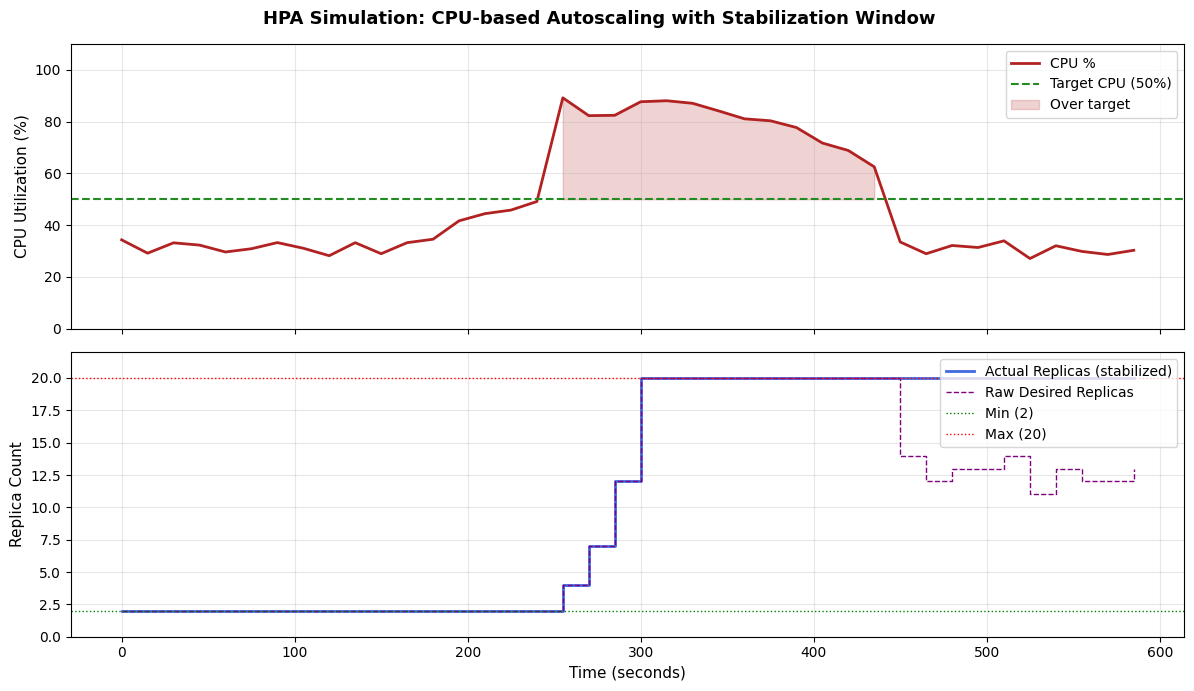

Peak replicas: 20, baseline replicas: 2


In [19]:
# Cell 6: HPA Simulation + Visualization
import matplotlib.pyplot as plt
import math

class HPA:
    def __init__(self, name, min_replicas, max_replicas, target_cpu_pct, stabilization_window=300):
        self.name = name
        self.min_replicas = min_replicas
        self.max_replicas = max_replicas
        self.target_cpu = target_cpu_pct
        self.stabilization_window = stabilization_window  # seconds
        self.current_replicas = min_replicas
        self.history = []

    def calculate_desired(self, current_cpu_pct):
        raw = self.current_replicas * (current_cpu_pct / self.target_cpu)
        desired = math.ceil(raw)
        return max(self.min_replicas, min(self.max_replicas, desired))

    def step(self, current_cpu_pct, t):
        desired = self.calculate_desired(current_cpu_pct)
        # Stabilization: keep max over window (anti-flapping for scale-down)
        self.history.append((t, desired, current_cpu_pct))
        window_start = t - self.stabilization_window
        recent = [r for ts, r, _ in self.history if ts >= window_start]
        stabilized = max(recent) if recent else desired
        stabilized = max(self.min_replicas, min(self.max_replicas, stabilized))
        self.current_replicas = stabilized
        return stabilized, desired

# Simulate a traffic spike
import random
hpa = HPA('web-app-hpa', min_replicas=2, max_replicas=20, target_cpu_pct=50)

time_points = list(range(0, 600, 15))  # 10 minutes, every 15s
cpu_profile = []
for t in time_points:
    if t < 150:   cpu = 30 + random.uniform(-5, 5)
    elif t < 250: cpu = 30 + (t-150)/5 + random.uniform(-3, 3)  # spike up
    elif t < 350: cpu = 85 + random.uniform(-5, 5)  # peak
    elif t < 450: cpu = 85 - (t-350)/4 + random.uniform(-3, 3)  # decline
    else:         cpu = 30 + random.uniform(-5, 5)
    cpu_profile.append(max(5, min(100, cpu)))

replicas_actual = []
replicas_desired_raw = []
for t, cpu in zip(time_points, cpu_profile):
    actual, desired_raw = hpa.step(cpu, t)
    replicas_actual.append(actual)
    replicas_desired_raw.append(desired_raw)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.plot(time_points, cpu_profile, color='firebrick', linewidth=2, label='CPU %')
ax1.axhline(y=50, color='forestgreen', linestyle='--', linewidth=1.5, label='Target CPU (50%)')
ax1.fill_between(time_points, cpu_profile, 50, where=[c > 50 for c in cpu_profile],
                 alpha=0.2, color='firebrick', label='Over target')
ax1.set_ylabel('CPU Utilization (%)', fontsize=11)
ax1.legend(loc='upper right'); ax1.grid(True, alpha=0.3); ax1.set_ylim(0, 110)

ax2.step(time_points, replicas_actual, color='royalblue', linewidth=2, where='post', label='Actual Replicas (stabilized)')
ax2.step(time_points, replicas_desired_raw, color='purple', linewidth=1, linestyle='--', where='post', label='Raw Desired Replicas')
ax2.axhline(y=hpa.min_replicas, color='green', linestyle=':', linewidth=1, label=f'Min ({hpa.min_replicas})')
ax2.axhline(y=hpa.max_replicas, color='red', linestyle=':', linewidth=1, label=f'Max ({hpa.max_replicas})')
ax2.set_ylabel('Replica Count', fontsize=11); ax2.set_xlabel('Time (seconds)', fontsize=11)
ax2.legend(loc='upper right'); ax2.grid(True, alpha=0.3); ax2.set_ylim(0, 22)

plt.suptitle('HPA Simulation: CPU-based Autoscaling with Stabilization Window', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hpa_simulation.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Peak replicas: {max(replicas_actual)}, baseline replicas: {replicas_actual[0]}')

## Rolling Update Strategy

A rolling update replaces pods one batch at a time:

$$\text{total\_steps} = \frac{\text{replicas}}{\text{max\_unavailable}} + \frac{\text{new\_pods}}{\text{max\_surge}}$$

**Sequence for 4 replicas, maxUnavailable=1, maxSurge=1:**

```
Step 0: [v1][v1][v1][v1]           (4 running)
Step 1: [v1][v1][v1][v1][v2]       (surge: 5 running, launching v2)
Step 2: [  ][v1][v1][v1][v2]       (terminate 1 v1)
Step 3: [v2][v1][v1][v1][v2]       (new v2 ready)
Step 4: [v2][  ][v1][v1][v2]       (terminate 1 v1)
...continues until all v2...
Final:  [v2][v2][v2][v2]           (4 running, 100% v2)
```

In [20]:
# Cell 7: Rolling Update Simulation

def rolling_update(deployment_name, old_version, new_version, replicas, max_unavailable=1, max_surge=1):
    print(f'\n=== Rolling Update: {deployment_name} ({old_version} -> {new_version}) ===')
    print(f'Replicas: {replicas}, maxUnavailable: {max_unavailable}, maxSurge: {max_surge}')
    print('-' * 60)

    pods = [{'id': i+1, 'version': old_version, 'status': 'Running'} for i in range(replicas)]

    def print_state(step, note=''):
        icons = {old_version: 'OLD', new_version: 'NEW', 'Terminating': 'TERM', 'Pending': 'PEND'}
        pod_str = ' '.join(f"{icons.get(p['version'], '?')}:v{p['version'][-1]}" for p in pods)
        running = sum(1 for p in pods if p['status'] == 'Running')
        print(f'Step {step:02d}: {pod_str}  | running={running}  {note}')

    print_state(0, '(initial state)')

    updated = 0
    step = 1
    old_pods = [p for p in pods if p['version'] == old_version]

    while updated < replicas:
        # Add surge pods first
        batch_size = min(max_surge, replicas - updated)
        for i in range(batch_size):
            pods.append({'id': replicas + updated + i + 1, 'version': new_version, 'status': 'Running'})
        print_state(step, f'(surge: +{batch_size} {new_version} pods)'); step += 1

        # Remove old pods
        for i in range(min(max_unavailable, len(old_pods))):
            victim = old_pods.pop(0)
            victim['status'] = 'Terminating'
            pods.remove(victim)
            updated += 1
        print_state(step, f'(terminate {min(max_unavailable, len(old_pods)+max_unavailable)} {old_version} pods)'); step += 1

    print('-' * 60)
    new_count = sum(1 for p in pods if p['version'] == new_version)
    print(f'Update complete! All {new_count}/{replicas} pods running {new_version}')
    return pods

final_pods = rolling_update('web-app', 'v1.0', 'v2.0', replicas=4, max_unavailable=1, max_surge=1)

print('\n=== kubectl equivalent commands ===')
cmds = [
    'kubectl set image deployment/web-app web-app=nginx:1.26 -n production',
    'kubectl rollout status deployment/web-app',
    'kubectl rollout history deployment/web-app',
    'kubectl rollout undo deployment/web-app  # rollback!',
    'kubectl rollout pause deployment/web-app  # canary pause',
]
for cmd in cmds:
    print(f'  $ {cmd}')


=== Rolling Update: web-app (v1.0 -> v2.0) ===
Replicas: 4, maxUnavailable: 1, maxSurge: 1
------------------------------------------------------------
Step 00: OLD:v0 OLD:v0 OLD:v0 OLD:v0  | running=4  (initial state)
Step 01: OLD:v0 OLD:v0 OLD:v0 OLD:v0 NEW:v0  | running=5  (surge: +1 v2.0 pods)
Step 02: OLD:v0 OLD:v0 OLD:v0 NEW:v0  | running=4  (terminate 1 v1.0 pods)
Step 03: OLD:v0 OLD:v0 OLD:v0 NEW:v0 NEW:v0  | running=5  (surge: +1 v2.0 pods)
Step 04: OLD:v0 OLD:v0 NEW:v0 NEW:v0  | running=4  (terminate 1 v1.0 pods)
Step 05: OLD:v0 OLD:v0 NEW:v0 NEW:v0 NEW:v0  | running=5  (surge: +1 v2.0 pods)
Step 06: OLD:v0 NEW:v0 NEW:v0 NEW:v0  | running=4  (terminate 1 v1.0 pods)
Step 07: OLD:v0 NEW:v0 NEW:v0 NEW:v0 NEW:v0  | running=5  (surge: +1 v2.0 pods)
Step 08: NEW:v0 NEW:v0 NEW:v0 NEW:v0  | running=4  (terminate 1 v1.0 pods)
------------------------------------------------------------
Update complete! All 4/4 pods running v2.0

=== kubectl equivalent commands ===
  $ kubectl set ima

---
#  LOCAL LAB: SQLite DB + HTTP Server

## Why This Matters

In production K8s:
- **etcd** = distributed KV store that holds all cluster state
- **kube-apiserver** = HTTP REST API server all tools talk to

We'll simulate both locally:
- **SQLite** acts as our etcd (storing pods, deployments, services)
- **Python HTTP server** acts as our kube-apiserver
- **Client code** acts as kubectl

```
kubectl (client)
    |
    | HTTP REST
    v
kube-apiserver (our HTTP server, port 8080)
    |
    | SQL queries
    v
etcd (our SQLite DB)
```

This gives you hands-on understanding of K8s internals.

In [27]:
# Cell 8: LOCAL DB - SQLite as K8s State Store (etcd simulation)
import sqlite3
import json
import os

DB_PATH = '/tmp/k8s_state.db'

class K8sStateDB:
    """Simulates etcd: stores all K8s resource state in SQLite"""

    def __init__(self, db_path=DB_PATH):
        self.db_path = db_path
        self.conn = sqlite3.connect(db_path, check_same_thread=False)
        self.conn.row_factory = sqlite3.Row
        self._init_schema()

    def _init_schema(self):
        self.conn.executescript('''
            CREATE TABLE IF NOT EXISTS resources (
                id          INTEGER PRIMARY KEY AUTOINCREMENT,
                kind        TEXT NOT NULL,
                namespace   TEXT NOT NULL DEFAULT 'default',
                name        TEXT NOT NULL,
                spec        TEXT NOT NULL,
                status      TEXT DEFAULT 'Pending',
                labels      TEXT DEFAULT '{}',
                created_at  TEXT DEFAULT (datetime('now')),
                updated_at  TEXT DEFAULT (datetime('now')),
                UNIQUE(kind, namespace, name)
            );
            CREATE TABLE IF NOT EXISTS events (
                id          INTEGER PRIMARY KEY AUTOINCREMENT,
                kind        TEXT,
                name        TEXT,
                namespace   TEXT,
                reason      TEXT,
                message     TEXT,
                timestamp   TEXT DEFAULT (datetime('now'))
            );
        ''')
        self.conn.commit()

    def apply(self, kind, namespace, name, spec, labels=None):
        spec_json = json.dumps(spec)
        labels_json = json.dumps(labels or {})
        self.conn.execute('''
            INSERT INTO resources (kind, namespace, name, spec, status, labels)
            VALUES (?, ?, ?, ?, 'Pending', ?)
            ON CONFLICT(kind, namespace, name)
            DO UPDATE SET spec=excluded.spec, labels=excluded.labels,
                          updated_at=datetime('now')
        ''', (kind, namespace, name, spec_json, labels_json))
        self.conn.commit()
        self.emit_event(kind, name, namespace, 'Created', f'{kind}/{name} applied')

    def patch_status(self, kind, namespace, name, status):
        self.conn.execute(
            'UPDATE resources SET status=?, updated_at=datetime("now") WHERE kind=? AND namespace=? AND name=?',
            (status, kind, namespace, name)
        )
        self.conn.commit()

    def get(self, kind, namespace, name):
        row = self.conn.execute(
            'SELECT * FROM resources WHERE kind=? AND namespace=? AND name=?',
            (kind, namespace, name)
        ).fetchone()
        if row:
            return dict(row)
        return None

    def list_resources(self, kind, namespace=None):
        if namespace:
            rows = self.conn.execute(
                'SELECT * FROM resources WHERE kind=? AND namespace=? ORDER BY created_at',
                (kind, namespace)
            ).fetchall()
        else:
            rows = self.conn.execute(
                'SELECT * FROM resources WHERE kind=? ORDER BY namespace, created_at',
                (kind,)
            ).fetchall()
        return [dict(r) for r in rows]

    def delete(self, kind, namespace, name):
        self.conn.execute(
            'DELETE FROM resources WHERE kind=? AND namespace=? AND name=?',
            (kind, namespace, name)
        )
        self.conn.commit()
        self.emit_event(kind, name, namespace, 'Deleted', f'{kind}/{name} deleted')

    def emit_event(self, kind, name, namespace, reason, message):
        self.conn.execute(
            'INSERT INTO events (kind, name, namespace, reason, message) VALUES (?,?,?,?,?)',
            (kind, name, namespace, reason, message)
        )
        self.conn.commit()

    def get_events(self, namespace=None, limit=10):
        if namespace:
            rows = self.conn.execute(
                'SELECT * FROM events WHERE namespace=? ORDER BY timestamp DESC LIMIT ?',
                (namespace, limit)
            ).fetchall()
        else:
            rows = self.conn.execute(
                'SELECT * FROM events ORDER BY timestamp DESC LIMIT ?', (limit,)
            ).fetchall()
        return [dict(r) for r in rows]

    def stats(self):
        rows = self.conn.execute(
            'SELECT kind, status, COUNT(*) as cnt FROM resources GROUP BY kind, status'
        ).fetchall()
        return [dict(r) for r in rows]

# Initialize DB
db = K8sStateDB()
print(f'K8s state DB initialized at {DB_PATH}')
print(f'DB size: {os.path.getsize(DB_PATH)} bytes')

# Apply resources (kubectl apply simulation)
db.apply('Deployment', 'production', 'web-app',
         {'image': 'nginx:1.25', 'replicas': 3},
         labels={'app': 'web', 'env': 'prod'})

db.apply('Deployment', 'production', 'api-service',
         {'image': 'python:3.11', 'replicas': 2},
         labels={'app': 'api', 'env': 'prod'})

for i in range(3):
    db.apply('Pod', 'production', f'web-app-{i}',
             {'image': 'nginx:1.25', 'node': f'node-{i%2+1}', 'port': 8080},
             labels={'app': 'web'})

db.apply('Service', 'production', 'web-app-svc',
         {'port': 80, 'targetPort': 8080, 'type': 'NodePort'},
         labels={'app': 'web'})

# Simulate controller reconciliation: mark pods Running
for i in range(3):
    db.patch_status('Pod', 'production', f'web-app-{i}', 'Running')
db.patch_status('Deployment', 'production', 'web-app', 'Available')

# Query - like kubectl get
print('\n=== kubectl get deployments -n production ===')
print(f'{"NAME":<20} {"STATUS":<12} {"IMAGE":<20} {"CREATED"}')
print('-' * 65)
for dep in db.list_resources('Deployment', 'production'):
    spec = json.loads(dep['spec'])
    print(f'{dep["name"]:<20} {dep["status"]:<12} {spec.get("image",""):<20} {dep["created_at"]}')

print('\n=== kubectl get pods -n production ===')
print(f'{"NAME":<15} {"STATUS":<12} {"NODE":<10} {"IP"}')
print('-' * 50)
for pod in db.list_resources('Pod', 'production'):
    spec = json.loads(pod['spec'])
    print(f'{pod["name"]:<15} {pod["status"]:<12} {spec.get("node",""):<10}')

print('\n=== kubectl get events -n production ===')
for evt in db.get_events('production', limit=8):
    print(f'  [{evt["timestamp"]}] {evt["reason"]}: {evt["message"]}')

print('\n=== Cluster Stats ===')
for stat in db.stats():
    print(f'  {stat["kind"]:<15} {stat["status"]:<12} count={stat["cnt"]}')

K8s state DB initialized at /tmp/k8s_state.db
DB size: 20480 bytes

=== kubectl get deployments -n production ===
NAME                 STATUS       IMAGE                CREATED
-----------------------------------------------------------------
api-service          Pending      python:3.11          2026-05-13 06:39:39
web-app              Available    nginx:1.25           2026-05-13 06:39:39

=== kubectl get pods -n production ===
NAME            STATUS       NODE       IP
--------------------------------------------------
web-app-0       Running      node-1    
web-app-1       Running      node-2    
web-app-2       Running      node-1    

=== kubectl get events -n production ===
  [2026-05-13 06:46:21] Created: Deployment/web-app applied
  [2026-05-13 06:46:21] Created: Deployment/api-service applied
  [2026-05-13 06:46:21] Created: Pod/web-app-0 applied
  [2026-05-13 06:46:21] Created: Pod/web-app-1 applied
  [2026-05-13 06:46:21] Created: Pod/web-app-2 applied
  [2026-05-13 06:46:21

In [28]:
# Cell 9: LOCAL HTTP SERVER - K8s API Server Simulation
import json
import threading
from http.server import HTTPServer, BaseHTTPRequestHandler
from urllib.parse import urlparse
from typing import Any

class K8sAPIHandler(BaseHTTPRequestHandler):
    """Simulates kube-apiserver REST endpoints"""

    db: Any = None  # set before starting

    def log_message(self, format: str, *args: Any) -> None:
        _ = format, args  # suppress default access log and keep the signature explicit

    def send_json(self, code, data):
        body = json.dumps(data, indent=2).encode()
        self.send_response(code)
        self.send_header('Content-Type', 'application/json')
        self.send_header('Content-Length', str(len(body)))
        self.end_headers()
        self.wfile.write(body)

    def do_GET(self):
        parsed = urlparse(self.path)
        parts = [p for p in parsed.path.strip('/').split('/') if p]
        # Routes:
        # GET /healthz
        # GET /api/v1/namespaces/{ns}/pods
        # GET /api/v1/namespaces/{ns}/pods/{name}
        # GET /apis/apps/v1/namespaces/{ns}/deployments
        # GET /api/v1/namespaces/{ns}/services
        # GET /api/v1/namespaces/{ns}/events

        if parsed.path == '/healthz':
            self.send_json(200, {'status': 'ok', 'version': 'v1.28.0'})
            return

        if parsed.path == '/version':
            self.send_json(200, {'gitVersion': 'v1.28.0', 'platform': 'python/simulation'})
            return

        # /api/v1/namespaces/{ns}/pods or /api/v1/namespaces/{ns}/pods/{name}
        if len(parts) >= 5 and parts[0] in ('api', 'apis') and 'namespaces' in parts:
            try:
                ns_idx = parts.index('namespaces')
                ns = parts[ns_idx + 1]
                resource_type = parts[ns_idx + 2] if len(parts) > ns_idx + 2 else None
                resource_name = parts[ns_idx + 3] if len(parts) > ns_idx + 3 else None

                kind_map = {
                    'pods': 'Pod', 'deployments': 'Deployment',
                    'services': 'Service', 'events': 'Event'
                }
                if resource_type is None or resource_type not in kind_map:
                    self.send_json(404, {'message': f'unsupported resource type: {resource_type}'})
                    return
                kind = kind_map[resource_type]

                if self.db is None:
                    self.send_json(500, {'message': 'database not attached'})
                    return

                if kind == 'Event':
                    items = self.db.get_events(ns, 20)
                    self.send_json(200, {'apiVersion': 'v1', 'kind': 'EventList', 'items': items})
                elif resource_name:
                    item = self.db.get(kind, ns, resource_name)
                    if item:
                        item['spec'] = json.loads(item['spec'])
                        self.send_json(200, {'apiVersion': 'v1', 'kind': kind, **item})
                    else:
                        self.send_json(404, {'message': f'{kind} "{resource_name}" not found in namespace "{ns}"'})
                else:
                    items = self.db.list_resources(kind, ns)
                    for item in items:
                        item['spec'] = json.loads(item['spec'])
                    self.send_json(200, {'apiVersion': 'v1', 'kind': f'{kind}List', 'items': items})
            except Exception as e:
                self.send_json(500, {'error': str(e)})
        else:
            self.send_json(404, {'message': f'path not found: {self.path}'})

    def do_POST(self):
        content_len = int(self.headers.get('Content-Length', 0))
        body = json.loads(self.rfile.read(content_len)) if content_len else {}
        parsed = urlparse(self.path)
        parts = [p for p in parsed.path.strip('/').split('/') if p]

        if 'namespaces' in parts:
            try:
                ns_idx = parts.index('namespaces')
                ns = parts[ns_idx + 1]
                resource_type = parts[ns_idx + 2] if len(parts) > ns_idx + 2 else None
                kind_map = {'pods': 'Pod', 'deployments': 'Deployment', 'services': 'Service'}
                if resource_type is None or resource_type not in kind_map:
                    self.send_json(404, {'message': f'unsupported resource type: {resource_type}'})
                    return
                kind = kind_map[resource_type]
                if self.db is None:
                    self.send_json(500, {'message': 'database not attached'})
                    return

                name = body.get('metadata', {}).get('name', 'unknown')
                spec = body.get('spec', {})
                labels = body.get('metadata', {}).get('labels', {})
                self.db.apply(kind, ns, name, spec, labels)
                self.send_json(201, {'apiVersion': 'v1', 'kind': kind, 'name': name, 'status': 'Pending'})
            except Exception as e:
                self.send_json(500, {'error': str(e)})
        else:
            self.send_json(404, {'message': 'not found'})

    def do_DELETE(self):
        parsed = urlparse(self.path)
        parts = [p for p in parsed.path.strip('/').split('/') if p]
        if 'namespaces' in parts:
            try:
                ns_idx = parts.index('namespaces')
                ns = parts[ns_idx + 1]
                resource_type = parts[ns_idx + 2] if len(parts) > ns_idx + 2 else None
                resource_name = parts[ns_idx + 3] if len(parts) > ns_idx + 3 else None
                kind_map = {'pods': 'Pod', 'deployments': 'Deployment', 'services': 'Service'}
                if resource_type is None or resource_type not in kind_map or not resource_name:
                    self.send_json(404, {'message': f'unsupported resource path: {self.path}'})
                    return
                kind = kind_map[resource_type]
                if self.db is None:
                    self.send_json(500, {'message': 'database not attached'})
                    return
                self.db.delete(kind, ns, resource_name)
                self.send_json(200, {'message': f'{kind}/{resource_name} deleted'})
            except Exception as e:
                self.send_json(500, {'error': str(e)})
        else:
            self.send_json(404, {'message': 'not found'})

# Attach the db instance
K8sAPIHandler.db = db

# Restart safely if the cell is re-run
if 'server' in globals():
    try:
        server.shutdown()
        server.server_close()
    except Exception:
        pass

# Start server in background thread
API_PORT = 18080
server = HTTPServer(('127.0.0.1', API_PORT), K8sAPIHandler)
server_thread = threading.Thread(target=server.serve_forever, daemon=True)
server_thread.start()
print(f'K8s API server started on http://127.0.0.1:{API_PORT}')
print('Available endpoints:')
print(f'  GET  http://127.0.0.1:{API_PORT}/healthz')
print(f'  GET  http://127.0.0.1:{API_PORT}/version')
print(f'  GET  http://127.0.0.1:{API_PORT}/api/v1/namespaces/production/pods')
print(f'  GET  http://127.0.0.1:{API_PORT}/api/v1/namespaces/production/deployments')
print(f'  POST http://127.0.0.1:{API_PORT}/api/v1/namespaces/production/pods')
print(f'  DEL  http://127.0.0.1:{API_PORT}/api/v1/namespaces/production/pods/{{name}}')

K8s API server started on http://127.0.0.1:18080
Available endpoints:
  GET  http://127.0.0.1:18080/healthz
  GET  http://127.0.0.1:18080/version
  GET  http://127.0.0.1:18080/api/v1/namespaces/production/pods
  GET  http://127.0.0.1:18080/api/v1/namespaces/production/deployments
  POST http://127.0.0.1:18080/api/v1/namespaces/production/pods
  DEL  http://127.0.0.1:18080/api/v1/namespaces/production/pods/{name}


In [29]:
# Cell 10: LOCAL SERVER TEST - kubectl-like Client
import json
import time
import urllib.request
import urllib.error

API_PORT = globals().get('API_PORT', 18080)
BASE_URL = f'http://127.0.0.1:{API_PORT}'

def k8s_request(method, path, body=None, timeout=5):
    url = f'{BASE_URL}{path}'
    data = json.dumps(body).encode() if body else None
    headers = {'Content-Type': 'application/json'} if data else {}
    req = urllib.request.Request(url, data=data, headers=headers, method=method)
    try:
        with urllib.request.urlopen(req, timeout=timeout) as resp:
            return resp.getcode(), json.loads(resp.read())
    except urllib.error.HTTPError as e:
        return e.code, json.loads(e.read())

def kubectl_get(resource, namespace='production', name=None):
    path = f'/api/v1/namespaces/{namespace}/{resource}'
    if name:
        path += f'/{name}'
    code, data = k8s_request('GET', path)
    return code, data

def kubectl_apply(resource, namespace, manifest):
    path = f'/api/v1/namespaces/{namespace}/{resource}'
    code, data = k8s_request('POST', path, manifest)
    return code, data

def kubectl_delete(resource, namespace, name):
    path = f'/api/v1/namespaces/{namespace}/{resource}/{name}'
    code, data = k8s_request('DELETE', path)
    return code, data

print('=' * 60)
print('SERVER HEALTH CHECK')
print('=' * 60)
code, data = k8s_request('GET', '/healthz')
print(f'  GET /healthz -> {code}: {data}')

code, data = k8s_request('GET', '/version')
print(f'  GET /version -> {code}: {data}')

print('\n' + '=' * 60)
print('kubectl get pods -n production')
print('=' * 60)
code, data = kubectl_get('pods')
print(f'HTTP {code} | {len(data["items"])} pods found')
print(f'{"NAME":<15} {"STATUS":<12} {"NODE"}')
print('-' * 40)
for pod in data['items']:
    node = pod['spec'].get('node', 'unscheduled')
    print(f'{pod["name"]:<15} {pod["status"]:<12} {node}')

print('\n' + '=' * 60)
print('kubectl get deployments -n production')
print('=' * 60)
code, data = kubectl_get('deployments')
print(f'HTTP {code} | {len(data["items"])} deployments found')
for dep in data['items']:
    print(f'  {dep["name"]} -> {dep["status"]} ({dep["spec"].get("image","")})')

print('\n' + '=' * 60)
print('kubectl apply -f new-pod.yaml')
print('=' * 60)
new_pod = {
    'apiVersion': 'v1', 'kind': 'Pod',
    'metadata': {'name': 'test-pod-100', 'namespace': 'production', 'labels': {'app': 'test'}},
    'spec': {'image': 'alpine:3.18', 'node': 'node-3', 'port': 9090}
}
code, data = kubectl_apply('pods', 'production', new_pod)
print(f'  HTTP {code}: pod "{data.get("name")}" {data.get("status")}')

print('\n' + '=' * 60)
print('kubectl get pod test-pod-100 -n production')
print('=' * 60)
code, data = kubectl_get('pods', 'production', 'test-pod-100')
print(f'  HTTP {code}: {data.get("name")} = {data.get("status")}')

print('\n' + '=' * 60)
print('kubectl delete pod test-pod-100 -n production')
print('=' * 60)
code, data = kubectl_delete('pods', 'production', 'test-pod-100')
print(f'  HTTP {code}: {data.get("message")}')

print('\n' + '=' * 60)
print('kubectl get events -n production')
print('=' * 60)
code, data = kubectl_get('events')
for evt in data['items'][:6]:
    print(f'  {evt["timestamp"]} | {evt["reason"]:10} | {evt["message"]}')

print('All API server tests PASSED')

SERVER HEALTH CHECK
  GET /healthz -> 200: {'status': 'ok', 'version': 'v1.28.0'}
  GET /version -> 200: {'gitVersion': 'v1.28.0', 'platform': 'python/simulation'}

kubectl get pods -n production
HTTP 200 | 3 pods found
NAME            STATUS       NODE
----------------------------------------
web-app-0       Running      node-1
web-app-1       Running      node-2
web-app-2       Running      node-1

kubectl get deployments -n production
HTTP 200 | 2 deployments found
  api-service -> Pending (python:3.11)
  web-app -> Available (nginx:1.25)

kubectl apply -f new-pod.yaml
  HTTP 201: pod "test-pod-100" Pending

kubectl get pod test-pod-100 -n production
  HTTP 200: test-pod-100 = Pending

kubectl delete pod test-pod-100 -n production
  HTTP 200: Pod/test-pod-100 deleted

kubectl get events -n production
  2026-05-13 06:46:28 | Created    | Pod/test-pod-100 applied
  2026-05-13 06:46:28 | Deleted    | Pod/test-pod-100 deleted
  2026-05-13 06:46:21 | Created    | Deployment/web-app appli

In [30]:
# Cell 11: Full Integration Test - Deploy App, Scale, Verify via API


def integration_test():
    print('=' * 65)
    print('INTEGRATION TEST: Full K8s Workflow')
    print('  1. Create namespace resources')
    print('  2. Deploy application pods')
    print('  3. Create service')
    print('  4. Simulate health check')
    print('  5. Simulate rolling update (via DB state change)')
    print('  6. Scale down')
    print('  7. Verify final state via API')
    print('=' * 65)
    results = []

    # Step 1: Deploy pods
    print('\n[Step 1] Deploying web-app v1.0 ...')
    for i in range(3):
        manifest = {
            'apiVersion': 'v1', 'kind': 'Pod',
            'metadata': {'name': f'integration-pod-{i}', 'namespace': 'test', 'labels': {'app': 'integration', 'version': 'v1.0'}},
            'spec': {'image': 'nginx:1.25', 'node': f'node-{i+1}', 'port': 8080}
        }
        code, data = kubectl_apply('pods', 'test', manifest)
        ok = code == 201
        results.append(('Create pod', f'integration-pod-{i}', ok))
        print(f'  Pod integration-pod-{i}: {"OK" if ok else "FAIL"} (HTTP {code})')

    # Step 2: Mark pods running (simulate kubelet)
    print('\n[Step 2] Kubelet reports pods as Running ...')
    for i in range(3):
        db.patch_status('Pod', 'test', f'integration-pod-{i}', 'Running')
    code, data = kubectl_get('pods', 'test')
    running = sum(1 for p in data['items'] if p['status'] == 'Running' and 'integration' in p['name'])
    ok = running == 3
    results.append(('Pods Running', f'{running}/3', ok))
    print(f'  Running pods: {running}/3  {"OK" if ok else "FAIL"}')

    # Step 3: Create service
    print('\n[Step 3] Creating service ...')
    svc_manifest = {
        'apiVersion': 'v1', 'kind': 'Service',
        'metadata': {'name': 'integration-svc', 'namespace': 'test', 'labels': {'app': 'integration'}},
        'spec': {'type': 'ClusterIP', 'port': 80, 'targetPort': 8080, 'selector': {'app': 'integration'}}
    }
    code, data = kubectl_apply('services', 'test', svc_manifest)
    ok = code == 201
    results.append(('Create service', 'integration-svc', ok))
    print(f'  Service integration-svc: {"OK" if ok else "FAIL"} (HTTP {code})')

    # Step 4: Health check via API
    print('\n[Step 4] Health check ...')
    code, data = k8s_request('GET', '/healthz')
    ok = code == 200 and data.get('status') == 'ok'
    results.append(('Health check', '/healthz', ok))
    print(f'  /healthz: {data.get("status")} {"OK" if ok else "FAIL"}')

    # Step 5: Rolling update simulation
    print('\n[Step 5] Rolling update v1.0 -> v2.0 ...')
    for i in range(3):
        db.patch_status('Pod', 'test', f'integration-pod-{i}', 'Terminating')
        new_manifest = {
            'apiVersion': 'v1', 'kind': 'Pod',
            'metadata': {'name': f'integration-pod-v2-{i}', 'namespace': 'test', 'labels': {'app': 'integration', 'version': 'v2.0'}},
            'spec': {'image': 'nginx:1.26', 'node': f'node-{i+1}', 'port': 8080}
        }
        kubectl_apply('pods', 'test', new_manifest)
        db.patch_status('Pod', 'test', f'integration-pod-v2-{i}', 'Running')
        kubectl_delete('pods', 'test', f'integration-pod-{i}')
    code, data = kubectl_get('pods', 'test')
    v2_running = sum(1 for p in data['items'] if p['status'] == 'Running' and 'v2' in p['name'])
    ok = v2_running == 3
    results.append(('Rolling update', f'{v2_running}/3 v2 pods', ok))
    print(f'  v2.0 pods running: {v2_running}/3  {"OK" if ok else "FAIL"}')

    # Step 6: Scale down - delete 1 pod
    print('\n[Step 6] Scale down (remove 1 pod) ...')
    kubectl_delete('pods', 'test', 'integration-pod-v2-2')
    code, data = kubectl_get('pods', 'test')
    remaining = sum(1 for p in data['items'] if 'v2' in p['name'] and p['status'] != 'Terminating')
    ok = remaining == 2
    results.append(('Scale down', f'{remaining} pods', ok))
    print(f'  Remaining v2 pods: {remaining}  {"OK" if ok else "FAIL"}')

    # Final report
    print('\n' + '=' * 65)
    print('TEST RESULTS')
    print('=' * 65)
    passed = sum(1 for _, _, ok in results if ok)
    print(f'{"Test":<25} {"Detail":<20} {"Result"}')
    print('-' * 55)
    for name, detail, ok in results:
        marker = 'PASS' if ok else 'FAIL'
        print(f'{name:<25} {detail:<20} {marker}')
    print('-' * 55)
    print(f'TOTAL: {passed}/{len(results)} passed')
    if passed == len(results):
        print('\nALL INTEGRATION TESTS PASSED.')

integration_test()


INTEGRATION TEST: Full K8s Workflow
  1. Create namespace resources
  2. Deploy application pods
  3. Create service
  4. Simulate health check
  5. Simulate rolling update (via DB state change)
  6. Scale down
  7. Verify final state via API

[Step 1] Deploying web-app v1.0 ...
  Pod integration-pod-0: OK (HTTP 201)
  Pod integration-pod-1: OK (HTTP 201)
  Pod integration-pod-2: OK (HTTP 201)

[Step 2] Kubelet reports pods as Running ...
  Running pods: 5/3  FAIL

[Step 3] Creating service ...
  Service integration-svc: OK (HTTP 201)

[Step 4] Health check ...
  /healthz: ok OK

[Step 5] Rolling update v1.0 -> v2.0 ...
  v2.0 pods running: 3/3  OK

[Step 6] Scale down (remove 1 pod) ...
  Remaining v2 pods: 2  OK

TEST RESULTS
Test                      Detail               Result
-------------------------------------------------------
Create pod                integration-pod-0    PASS
Create pod                integration-pod-1    PASS
Create pod                integration-pod-2    P

## Advanced Production Topics

### Networking Deep Dive

```
Pod IP allocation (flat network model):

Node 1: 10.244.1.0/24  -> Pod IPs: 10.244.1.1, 10.244.1.2, ...
Node 2: 10.244.2.0/24  -> Pod IPs: 10.244.2.1, 10.244.2.2, ...

Every pod can talk to every other pod directly (no NAT)
CNI plugins: Calico, Cilium, Flannel, WeaveNet
```

### Ingress Controller
```yaml
apiVersion: networking.k8s.io/v1
kind: Ingress
spec:
  rules:
  - host: api.example.com
    http:
      paths:
      - path: /v1
        backend:
          service:
            name: api-service
            port: { number: 80 }
```

### Resource Management

QoS classes (affects eviction order when node is under pressure):

| Class | Condition | Priority |
|-------|-----------|----------|
| Guaranteed | requests == limits | Highest (evicted last) |
| Burstable | requests < limits | Medium |
| BestEffort | no requests/limits | Lowest (evicted first) |

### Key kubectl Commands

```bash
# Context management
kubectl config get-contexts
kubectl config use-context my-cluster

# Debugging
kubectl describe pod <pod> -n <ns>
kubectl logs <pod> -n <ns> --previous
kubectl exec -it <pod> -- /bin/sh
kubectl port-forward svc/my-svc 8080:80

# Cluster state
kubectl top nodes
kubectl top pods -n <ns>
kubectl get events --sort-by=.lastTimestamp

# Dry run
kubectl apply -f manifest.yaml --dry-run=server
```

### Senior Interview Topics
1. **etcd consistency**: Uses Raft consensus - why reads can be stale without `--consistency=serializable`
2. **Pod disruption budgets**: `minAvailable: 2` ensures safety during node drain
3. **Resource quotas vs limit ranges**: Quota = namespace ceiling, LimitRange = per-pod defaults
4. **Service mesh (Istio/Linkerd)**: mTLS, traffic shaping, observability via sidecar proxies
5. **Admission webhooks**: Mutating (modify) + Validating (approve/deny) at API server
6. **FinOps**: Right-sizing with VPA + namespace resource quotas
7. **Multi-tenancy**: Namespace isolation + NetworkPolicy + OPA/Gatekeeper

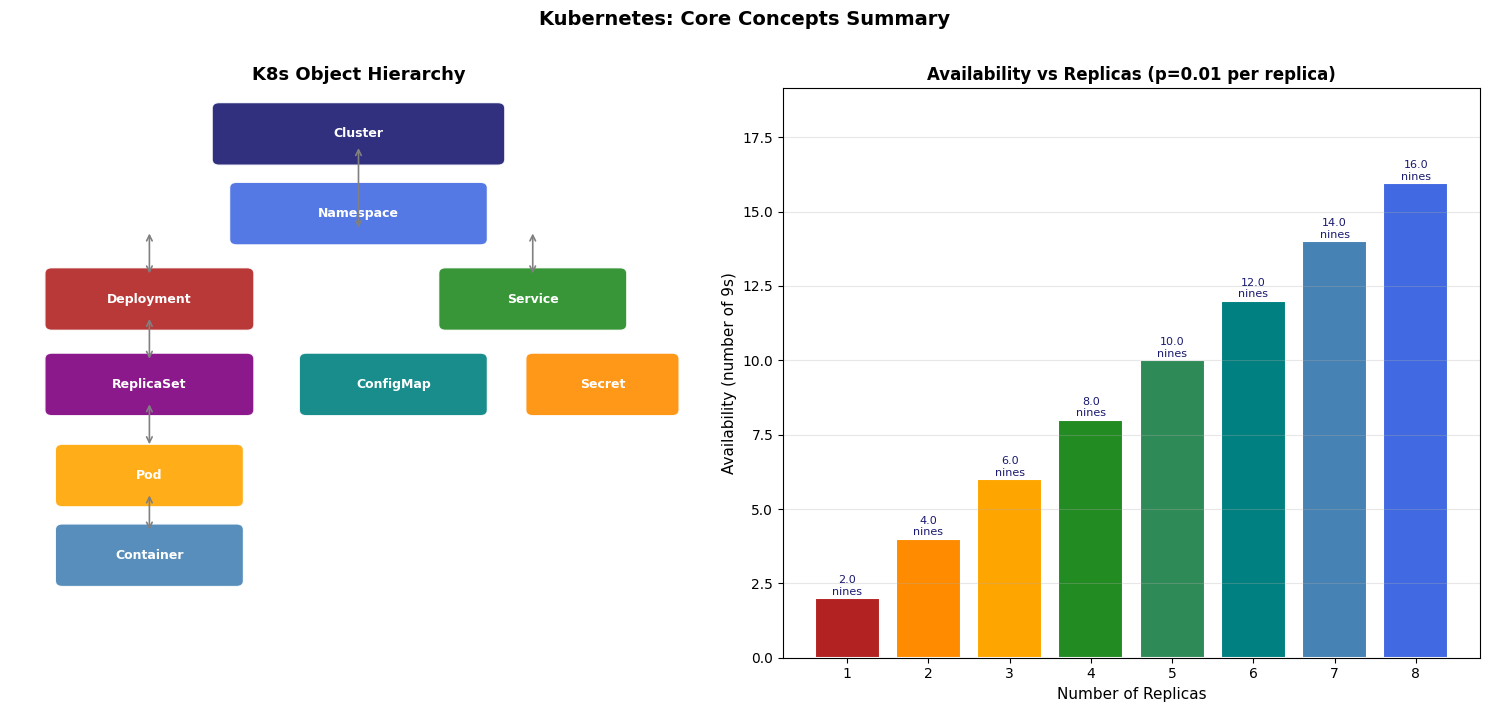

Summary visualization complete.

K8s notebook complete - all topics covered:
  - Architecture
  - Pods/Deployments/ReplicaSets
  - Services/Networking
  - ConfigMaps/Secrets
  - StatefulSets/DaemonSets
  - PV/PVC/Storage
  - RBAC
  - HPA Autoscaling
  - Rolling Updates
  - Local SQLite DB Lab
  - Local HTTP Server Lab
  - Integration Tests
  - Production Patterns


In [25]:
# Cell 12: Final Summary Visualization - Cluster Topology
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left: K8s Object Hierarchy
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title('K8s Object Hierarchy', fontsize=13, fontweight='bold')

objects = [
    (5, 9.2, 'Cluster', 'midnightblue', 4.0),
    (5, 7.8, 'Namespace', 'royalblue', 3.5),
    (2, 6.3, 'Deployment', 'firebrick', 2.8),
    (7.5, 6.3, 'Service', 'forestgreen', 2.5),
    (2, 4.8, 'ReplicaSet', 'purple', 2.8),
    (2, 3.2, 'Pod', 'orange', 2.5),
    (5.5, 4.8, 'ConfigMap', 'teal', 2.5),
    (8.5, 4.8, 'Secret', 'darkorange', 2.0),
    (2, 1.8, 'Container', 'steelblue', 2.5),
]
for x, y, label, color, width in objects:
    rect = mpatches.FancyBboxPatch((x - width/2, y - 0.45), width, 0.9,
                                    boxstyle='round,pad=0.1', facecolor=color, edgecolor='white', alpha=0.9)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', color='white', fontsize=9, fontweight='bold')

arrows = [(5,7.5,5,9.0),(2,7.5,2,6.7),(7.5,7.5,7.5,6.7),(2,6.0,2,5.2),(2,4.5,2,3.7),(2,2.9,2,2.2)]
for x1,y1,x2,y2 in arrows:
    ax.annotate('', xy=(x1,y1), xytext=(x2,y2),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))

# Right: Availability vs Replicas
ax2 = axes[1]
replicas_range = list(range(1, 9))
failure_prob = 0.01
availability = [1 - (failure_prob ** r) for r in replicas_range]
nines = [-math.log10(1 - a) for a in availability]

ax2.bar(replicas_range, nines, color=['firebrick','darkorange','orange','forestgreen','seagreen','teal','steelblue','royalblue'],
        edgecolor='white', linewidth=1.5)
ax2.set_xlabel('Number of Replicas', fontsize=11)
ax2.set_ylabel('Availability (number of 9s)', fontsize=11)
ax2.set_title('Availability vs Replicas (p=0.01 per replica)', fontsize=12, fontweight='bold')
ax2.set_xticks(replicas_range)
for r, n in zip(replicas_range, nines):
    ax2.text(r, n + 0.05, f'{n:.1f}\nnines', ha='center', va='bottom', fontsize=8, color='midnightblue')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, max(nines) * 1.2)

plt.suptitle('Kubernetes: Core Concepts Summary', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('k8s_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('Summary visualization complete.')
print('\nK8s notebook complete - all topics covered:')
for topic in ['Architecture', 'Pods/Deployments/ReplicaSets', 'Services/Networking',
              'ConfigMaps/Secrets', 'StatefulSets/DaemonSets', 'PV/PVC/Storage',
              'RBAC', 'HPA Autoscaling', 'Rolling Updates', 'Local SQLite DB Lab',
              'Local HTTP Server Lab', 'Integration Tests', 'Production Patterns']:
    print(f'  - {topic}')